# Trabajo Práctico Integrador: Análisis de Desempeño y Gestión de Cursos 🎓
**Materia:** Análisis de Datos Inicial  
**Carrera:** Tecnicatura Universitaria en Programación (TUP)

**Integrantes del grupo:**
1. Marcos Vega
2. Luciano Molaro
3. Facundo Zumaeta

**Entrega:** Segundo Parcial (Recuperatorio) — Hitos 1 a 5 + Tablero de Control en Grafana

---

## Hito 1: Elección y Planteo 🎯

**Dataset elegido:** `dataset_CursosUdemy_modificado.csv`

- El dataset contiene información sobre **5.027 cursos** de la plataforma de e-learning **Udemy** (cumple el mínimo de 5.000 registros exigido por la consigna). Incluye variables como cantidad de estudiantes inscriptos, cantidad de reseñas, calificación promedio, duración del curso, número de clases, nivel del curso, instructor y precios (original y con descuento).
- Los datos fueron **modificados intencionalmente** para incluir valores nulos, inconsistencias de formato y datos inválidos, con el objetivo de aplicar técnicas de limpieza y transformación (ETL).
- En este contexto educativo, cada *curso* es la unidad de análisis y los *estudiantes inscriptos* representan el alcance/desempeño de cada propuesta formativa.

**Objetivos del Análisis (Preguntas de alta complejidad a responder):**
1. **Pregunta 1:** ¿Qué combinación de duración, cantidad de clases y nivel del curso maximiza la cantidad de estudiantes y la calificación promedio?
2. **Pregunta 2:** ¿Existe una relación entre el precio (original y con descuento) y la calificación promedio de los cursos?
3. **Pregunta 3:** ¿Qué características distinguen a los cursos con mayor cantidad de estudiantes respecto del resto?

In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

---
## Hito 2: ETL y Calidad de Datos 🧹

En esta sección cargamos los datos y realizamos una auditoría inicial para entender con qué estamos trabajando. Luego aplicamos un proceso de ETL robusto: limpieza de tipos, normalización de strings, tratamiento de nulos, eliminación de *outliers* y *feature engineering*.

In [2]:
# 1. Carga de datos
df = pd.read_csv('dataset_CursosUdemy_modificado.csv')

# 2. Auditoría inicial
print("--- Primeras 5 filas del dataset ---")
display(df.head())

print("\n--- Información del dataset (Tipos de datos y nulos) ---")
df.info()

print("\n--- Cantidad de valores nulos por columna ---")
print(df.isnull().sum())

print(f"\nCantidad de filas duplicadas: {df.duplicated().sum()}")

--- Primeras 5 filas del dataset ---


,course_name,instructor,course url,course image,course description,reviews_avg,reviews_count,course_duration,lectures_count,level,price_after_discount,main_price,course_flag,students_count,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,2022 Complete Python Bootcamp From Zero to Her...,Jose Portilla,https://www.udemy.com/course/complete-python-b...,https://img-b.udemycdn.com/course/240x135/5678...,Learn Python like a Professional Start from t...,Rating: 4.6 out of 5,440383 reviews,22 total hours,155 lectures,All Levels,Current price: E£319.99,"Original price: E£1,399.99",NaN,"1,629,692 students",NaN,NaN,NaN,NaN
1,The Web Developer Bootcamp 2022,Colt Steele,https://www.udemy.com/course/the-web-developer...,https://img-b.udemycdn.com/course/240x135/6252...,COMPLETELY REDONE - The only course you need t...,Rating: 4.7 out of 5,248508 reviews,64 total hours,615 lectures,All Levels,Current price: E£269.99,"Original price: E£1,399.99",NaN,"830,559 students",NaN,NaN,NaN,NaN
2,The Complete 2022 Web Development Bootcamp,Dr. Angela Yu,https://www.udemy.com/course/the-complete-web-...,https://img-b.udemycdn.com/course/240x135/1565...,Become a Full-Stack Web Developer with just ON...,Rating: 4.7 out of 5,234837 reviews,65.5 total hours,490 lectures,All Levels,Current price: E£349.99,"Original price: E£1,699.99",Bestseller,"794,897 students",NaN,NaN,NaN,NaN
3,Angular - The Complete Guide (2023 Edition),Maximilian Schwarzmüller,https://www.udemy.com/course/the-complete-guid...,https://img-b.udemycdn.com/course/240x135/7561...,"Master Angular 14 (formerly ""Angular 2"") and b...",Rating: 4.6 out of 5,174576 reviews,34.5 total hours,472 lectures,All Levels,Current price: E£319.99,"Original price: E£1,599.99",Bestseller,"634,196 students",NaN,NaN,NaN,NaN
4,Java Programming Masterclass covering Java 11 ...,"Tim Buchalka, Tim Buchalka's Learn Programming...",https://www.udemy.com/course/java-the-complete...,https://img-b.udemycdn.com/course/240x135/5336...,Learn Java In This Course And Become a Compute...,Rating: 4.5 out of 5,171838 reviews,80.5 total hours,401 lectures,advanced,Current price: E£349.99,Original price: E£849.99,Bestseller,"727,934 students",NaN,NaN,NaN,NaN



--- Información del dataset (Tipos de datos y nulos) ---
<class 'pandas.DataFrame'>
RangeIndex: 5027 entries, 0 to 5026
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   course_name           5013 non-null   str  
 1   instructor            5016 non-null   str  
 2   course url            5020 non-null   str  
 3   course image          5017 non-null   str  
 4   course description    5016 non-null   str  
 5   reviews_avg           4781 non-null   str  
 6   reviews_count         4769 non-null   str  
 7   course_duration       4775 non-null   str  
 8   lectures_count        4766 non-null   str  
 9   level                 5021 non-null   str  
 10  price_after_discount  5017 non-null   str  
 11  main_price            4799 non-null   str  
 12  course_flag           518 non-null    str  
 13  students_count        4772 non-null   str  
 14  Unnamed: 14           3 non-null      str  
 15  Unnamed:

### Aplicación de Limpieza (Data Cleaning + Feature Engineering)

Procesamos los datos sucios: convertimos a numérico las columnas que vienen como texto (con expresiones regulares), normalizamos categorías, tratamos los nulos, eliminamos *outliers* con el método IQR y creamos nuevas variables derivadas.

In [3]:
# Copiamos el dataset para trabajar de forma segura
df = df.copy()

# Eliminamos columnas vacías generadas por el archivo original
df.drop(columns=["Unnamed: 14", "Unnamed: 15", "Unnamed: 16", "Unnamed: 17"],
        inplace=True, errors='ignore')

# -------------------------------
# 1. CONVERSIÓN DE NUMÉRICOS (datos sucios en formato texto -> float)
# -------------------------------
df["reviews_avg"]          = pd.to_numeric(df["reviews_avg"].astype(str).str.extract(r'(\d+\.\d+)')[0], errors='coerce')
df["reviews_count"]        = pd.to_numeric(df["reviews_count"].astype(str).str.replace(",", "").str.extract(r'(\d+)')[0], errors='coerce')
df["students_count"]       = pd.to_numeric(df["students_count"].astype(str).str.replace(",", "").str.extract(r'(\d+)')[0], errors='coerce')
df["course_duration"]      = pd.to_numeric(df["course_duration"].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
df["lectures_count"]       = pd.to_numeric(df["lectures_count"].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df["price_after_discount"] = pd.to_numeric(df["price_after_discount"].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
df["main_price"]           = pd.to_numeric(df["main_price"].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

# -------------------------------
# 2. NORMALIZACIÓN DE STRINGS
# -------------------------------
df["level"]      = df["level"].astype(str).str.strip().str.lower()
df["instructor"] = df["instructor"].astype(str).str.strip()

# REFINAMIENTO: algunas filas mal alineadas dejaron valores de precio dentro de 'level'.
# Conservamos únicamente las categorías de nivel válidas.
niveles_validos = ["all levels", "beginner", "intermediate", "advanced", "expert"]
df = df[df["level"].isin(niveles_validos)]

# -------------------------------
# 3. TRATAMIENTO DE NULOS
# -------------------------------
df["course_flag"] = df["course_flag"].fillna("No Bestseller")          # ausencia de flag = no bestseller
df = df.dropna(subset=["students_count", "reviews_avg"])               # variables clave: no se imputan

# REFINAMIENTO: imputación por mediana en variables secundarias (robusta a outliers)
for col in ["course_duration", "lectures_count", "main_price"]:
    df[col] = df[col].fillna(df[col].median())

# -------------------------------
# 4. ELIMINACIÓN DE OUTLIERS (método IQR)
# -------------------------------
def eliminar_outliers(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    li, ls = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return data[(data[columna] >= li) & (data[columna] <= ls)]

df = eliminar_outliers(df, "students_count")
df = eliminar_outliers(df, "reviews_count")

# -------------------------------
# 5. FEATURE ENGINEERING (nuevas variables)
# -------------------------------
df["duracion_por_clase"] = df["course_duration"] / df["lectures_count"]   # ritmo del curso
df["ratio_reviews"]      = df["reviews_count"] / df["students_count"]      # nivel de interacción

# Evitamos infinitos por divisiones por cero y volvemos a imputar
for col in ["duracion_por_clase", "ratio_reviews"]:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    df[col] = df[col].fillna(df[col].median())

# Variables categóricas derivadas (útiles para el análisis y el dashboard)
df["franja_rating"]   = pd.cut(df["reviews_avg"], [0, 3.5, 4.0, 4.5, 5.01],
                               labels=["<3.5", "3.5-4.0", "4.0-4.5", "4.5-5.0"])
df["segmento_precio"] = pd.cut(df["price_after_discount"], [0, 100, 250, 500, 1000],
                               labels=["Bajo (<100)", "Medio (100-250)", "Alto (250-500)", "Premium (>500)"])
umbral_top = df["students_count"].quantile(0.90)
df["top_curso"]   = np.where(df["students_count"] >= umbral_top, "Top 10%", "Resto")
df["nivel_label"] = df["level"].str.title()

# Verificamos que la limpieza haya sido exitosa
print(f"Filas finales: {df.shape[0]}  |  Columnas: {df.shape[1]}  |  Nulos restantes: {df.isnull().sum().sum()}")
df.info()

Filas finales: 3448  |  Columnas: 20  |  Nulos restantes: 0
<class 'pandas.DataFrame'>
Index: 3448 entries, 781 to 5024
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   course_name           3448 non-null   str     
 1   instructor            3448 non-null   str     
 2   course url            3448 non-null   str     
 3   course image          3448 non-null   str     
 4   course description    3448 non-null   str     
 5   reviews_avg           3448 non-null   float64 
 6   reviews_count         3448 non-null   float64 
 7   course_duration       3448 non-null   float64 
 8   lectures_count        3448 non-null   float64 
 9   level                 3448 non-null   str     
 10  price_after_discount  3448 non-null   float64 
 11  main_price            3448 non-null   float64 
 12  course_flag           3448 non-null   str     
 13  students_count        3448 non-null   float64 
 14  duracion_p

Durante el proceso de ETL se realizaron las siguientes tareas:

- **Conversión de tipos:** columnas numéricas que estaban en formato texto se transformaron con expresiones regulares (rating, reseñas, estudiantes, duración, clases y precios).
- **Normalización de strings:** estandarización de `level` e `instructor`.
- **Corrección de inconsistencias:** se descartaron filas mal alineadas que habían contaminado la columna `level` con valores de precio.
- **Tratamiento de nulos:** eliminación de registros sin las variables clave (`students_count`, `reviews_avg`) e **imputación por mediana** en las variables secundarias.
- **Eliminación de outliers:** método del rango intercuartílico (IQR) sobre cantidad de estudiantes y reseñas.
- **Feature Engineering:** `duracion_por_clase`, `ratio_reviews` (interacción), `franja_rating`, `segmento_precio` y `top_curso`.

El resultado es un dataset limpio, consistente y enriquecido, listo para el análisis y para alimentar el dashboard.

In [4]:
# Exportamos el DataFrame limpio. Este archivo alimenta el tablero de Grafana del Hito 4.
df.to_csv("datos_limpios.csv", index=False)
print("✅ Exportado 'datos_limpios.csv' con", len(df), "registros listos para el dashboard.")

✅ Exportado 'datos_limpios.csv' con 3448 registros listos para el dashboard.


---
## Hito 3: Visualización Dinámica y Análisis 📊

Exploramos los datos con estadística descriptiva y **seis visualizaciones profesionales** (Matplotlib/Seaborn) que responden a las tres preguntas del Hito 1. Cada gráfico incluye título, ejes etiquetados y un análisis escrito de lo que "dice".

In [5]:
# Estadística descriptiva de las variables numéricas
df.describe().round(2)

,reviews_avg,reviews_count,course_duration,lectures_count,price_after_discount,main_price,students_count,duracion_por_clase,ratio_reviews
count,3448.00,3448.00,3448.00,3448.00,3448.00,3448.00,3448.00,3448.00,3448.00
mean,4.27,478.97,10.62,85.05,253.87,348.26,8518.86,0.17,0.11
std,0.42,420.12,12.87,87.83,69.15,287.16,9902.61,0.46,0.08
min,1.70,124.00,1.00,5.00,1.00,1.00,299.00,0.00,0.00
25%,4.10,185.00,3.50,33.00,229.99,1.00,1973.25,0.08,0.04
50%,4.40,300.00,7.00,57.00,269.99,269.99,4574.00,0.11,0.11
75%,4.60,618.00,12.50,101.00,269.99,619.99,10585.25,0.15,0.17
max,5.00,2039.00,183.50,800.00,999.99,999.99,51605.00,8.00,0.54


### Visualización 1: Distribución de las Calificaciones

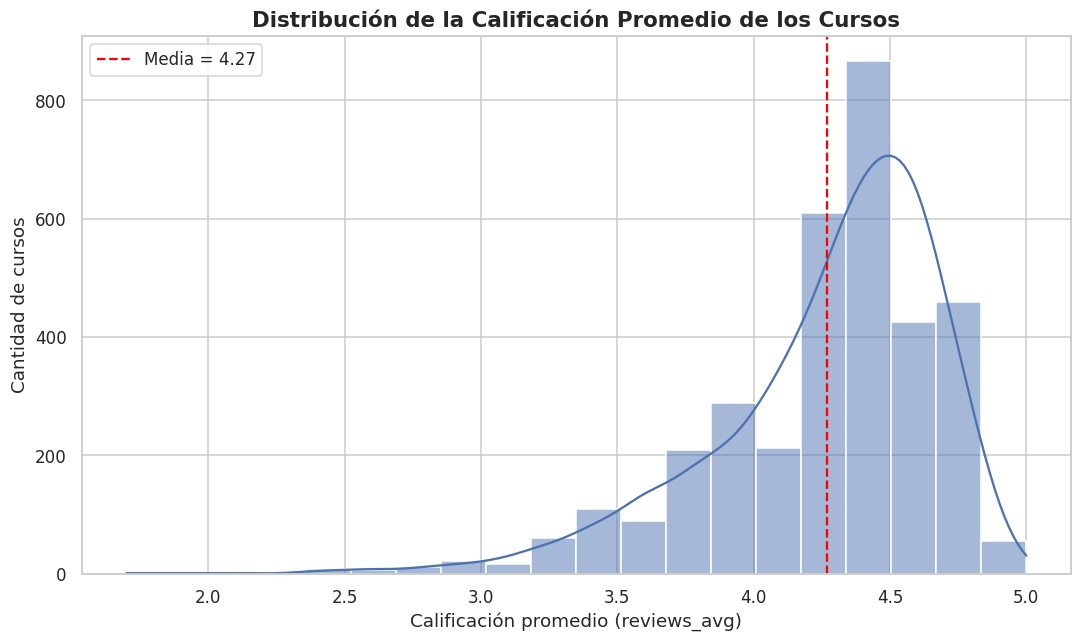

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df["reviews_avg"], bins=20, kde=True, color="#4C72B0")
plt.axvline(df["reviews_avg"].mean(), color="red", ls="--", lw=1.5,
            label=f"Media = {df['reviews_avg'].mean():.2f}")
plt.title("Distribución de la Calificación Promedio de los Cursos", fontsize=14, fontweight="bold")
plt.xlabel("Calificación promedio (reviews_avg)")
plt.ylabel("Cantidad de cursos")
plt.legend()
plt.tight_layout()
plt.show()

**Conclusión V1:** Las calificaciones están **fuertemente sesgadas hacia valores altos**: la media ronda **4.27** y la mediana **4.4**, y cerca del **40 %** de los cursos supera 4.5. Son muy pocos los cursos por debajo de 3.5. Esto indica que, en Udemy, una buena calificación es la norma y *no* un factor diferenciador por sí solo: para destacar hay que mirar otras variables.

### Visualización 2: Estudiantes Promedio por Nivel (Pregunta 1)

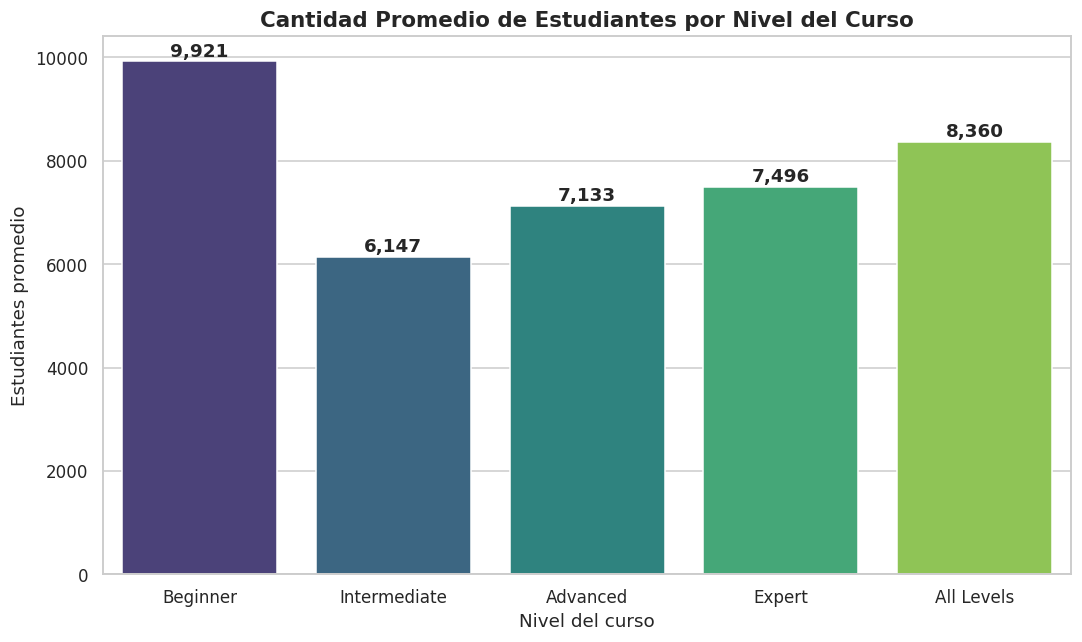

In [7]:
orden_niv = ["Beginner", "Intermediate", "Advanced", "Expert", "All Levels"]
g = df.groupby("nivel_label")["students_count"].mean().reindex(orden_niv)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=g.index, y=g.values, hue=g.index, palette="viridis", legend=False)
for i, v in enumerate(g.values):
    ax.text(i, v + 100, f"{v:,.0f}", ha="center", fontweight="bold")
plt.title("Cantidad Promedio de Estudiantes por Nivel del Curso", fontsize=14, fontweight="bold")
plt.xlabel("Nivel del curso")
plt.ylabel("Estudiantes promedio")
plt.tight_layout()
plt.show()

**Conclusión V2:** Los cursos **Beginner** lideran ampliamente con ~**9.921** estudiantes promedio, seguidos por los "All Levels" (~8.360). Los niveles **Intermediate** y **Advanced** captan bastante menos público (~6.100–7.100). El mensaje para la Pregunta 1 es claro: el contenido **introductorio / sin requisitos previos** es el que maximiza el alcance.

### Visualización 3: Precio vs. Calificación (Pregunta 2)

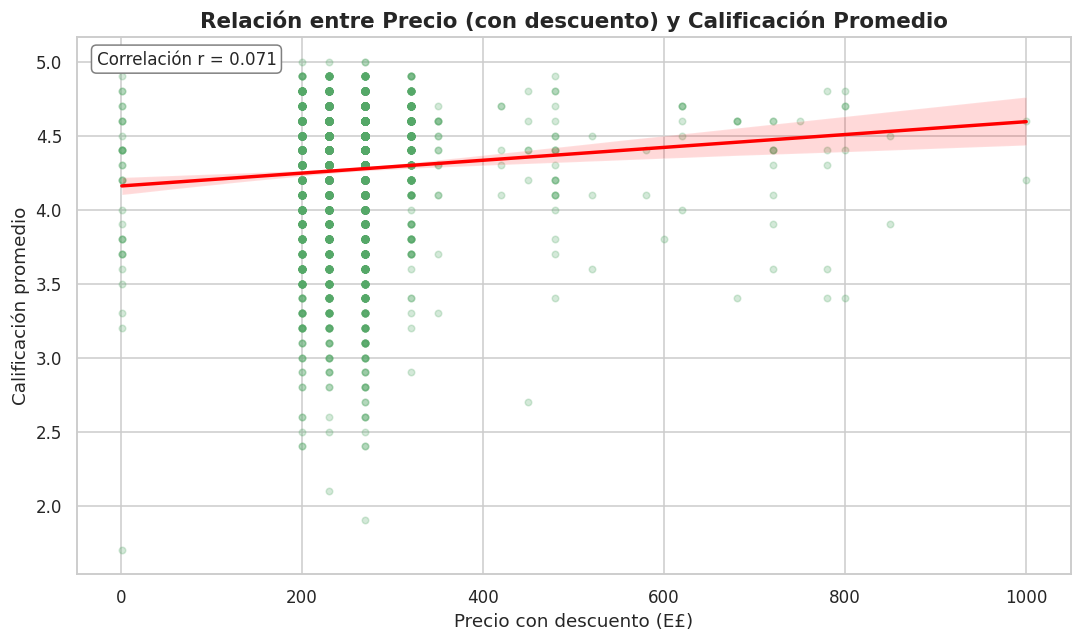

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="price_after_discount", y="reviews_avg",
            scatter_kws={"alpha": 0.25, "s": 18, "color": "#55A868"},
            line_kws={"color": "red"})
r = df["price_after_discount"].corr(df["reviews_avg"])
plt.annotate(f"Correlación r = {r:.3f}", xy=(0.02, 0.95), xycoords="axes fraction",
             fontsize=11, bbox=dict(boxstyle="round", fc="white", ec="gray"))
plt.title("Relación entre Precio (con descuento) y Calificación Promedio", fontsize=14, fontweight="bold")
plt.xlabel("Precio con descuento (E£)")
plt.ylabel("Calificación promedio")
plt.tight_layout()
plt.show()

**Conclusión V3:** La correlación entre precio y calificación es **prácticamente nula (r ≈ 0.07)**: la recta de regresión es casi plana. Responde directamente a la Pregunta 2 → **el precio no explica la calidad percibida**. Cursos caros y baratos obtienen calificaciones similares, por lo que subir el precio no garantiza mejores reseñas.

### Visualización 4: Dispersión de Estudiantes por Nivel

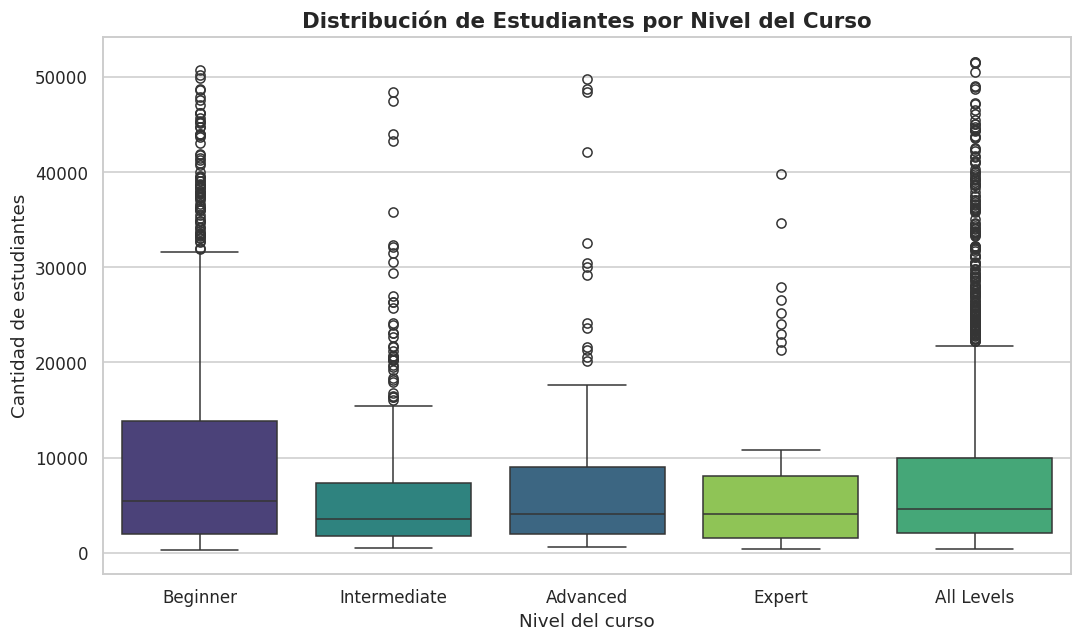

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="nivel_label", y="students_count", order=orden_niv,
            hue="nivel_label", palette="viridis", legend=False)
plt.title("Distribución de Estudiantes por Nivel del Curso", fontsize=14, fontweight="bold")
plt.xlabel("Nivel del curso")
plt.ylabel("Cantidad de estudiantes")
plt.tight_layout()
plt.show()

**Conclusión V4:** Más allá del promedio, el *boxplot* muestra que **Beginner** y **All Levels** no solo tienen medianas más altas sino también una mayor proporción de cursos masivos (cajas y bigotes superiores más altos). La gran dispersión confirma que dentro de cada nivel conviven cursos muy populares con otros de bajo alcance.

### Visualización 5: Matriz de Correlación

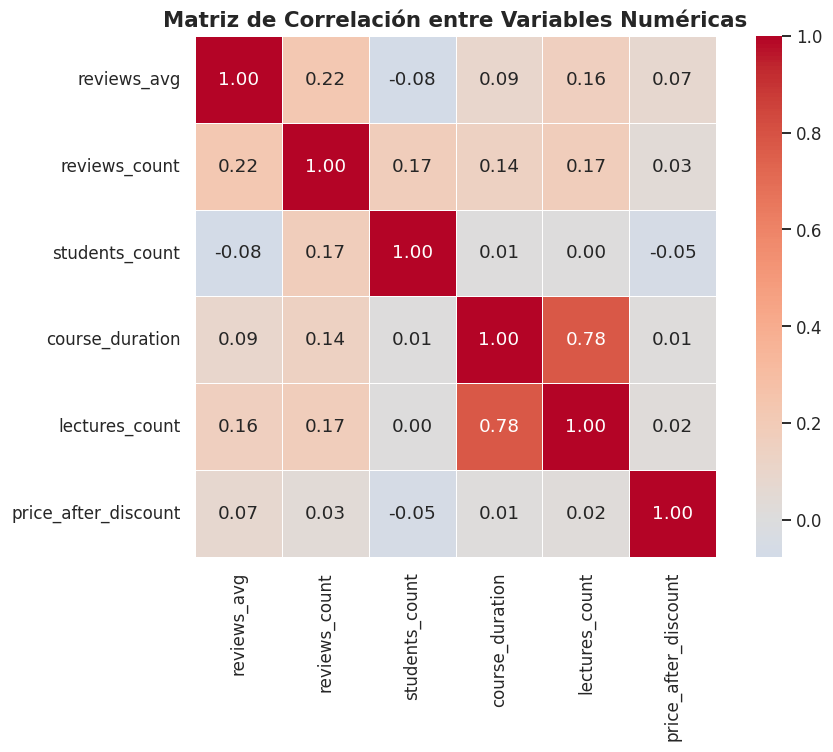

In [10]:
plt.figure(figsize=(9, 7))
cols = ["reviews_avg", "reviews_count", "students_count",
        "course_duration", "lectures_count", "price_after_discount"]
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=.5)
plt.title("Matriz de Correlación entre Variables Numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Conclusión V5:** La variable más asociada a `students_count` es `reviews_count` (r ≈ 0.17): a más estudiantes, más reseñas en términos absolutos. En cambio, `course_duration`, `lectures_count` y `price_after_discount` **no muestran relación relevante** con el alcance ni con la calificación. Esto refina la Pregunta 1: la duración y la cantidad de clases **no** son palancas para conseguir más estudiantes.

### Visualización 6: Cursos Top 10% vs. Resto (Pregunta 3)

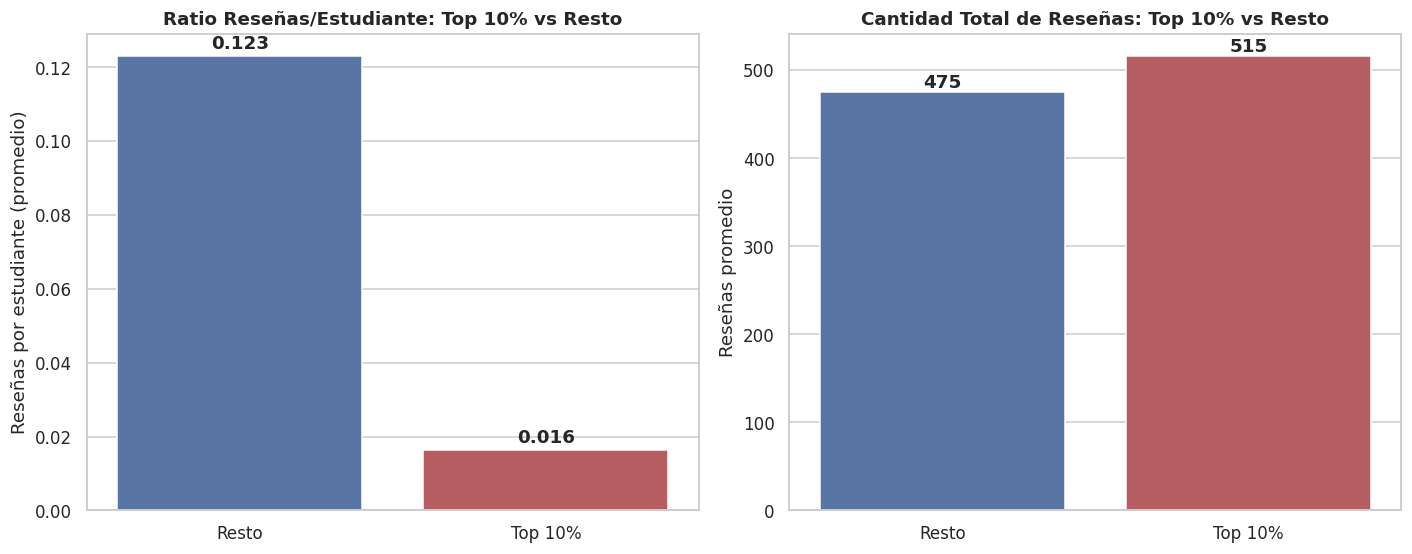

In [11]:
C = {"Top 10%": "#C44E52", "Resto": "#4C72B0"}
orden = ["Resto", "Top 10%"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

r1 = df.groupby("top_curso")["ratio_reviews"].mean().reindex(orden)
sns.barplot(x=r1.index, y=r1.values, ax=axes[0],
            hue=r1.index, palette=[C[k] for k in r1.index], legend=False)
for i, v in enumerate(r1.values):
    axes[0].text(i, v + 0.002, f"{v:.3f}", ha="center", fontweight="bold")
axes[0].set_title("Ratio Reseñas/Estudiante: Top 10% vs Resto", fontweight="bold")
axes[0].set_ylabel("Reseñas por estudiante (promedio)"); axes[0].set_xlabel("")

r2 = df.groupby("top_curso")["reviews_count"].mean().reindex(orden)
sns.barplot(x=r2.index, y=r2.values, ax=axes[1],
            hue=r2.index, palette=[C[k] for k in r2.index], legend=False)
for i, v in enumerate(r2.values):
    axes[1].text(i, v + 5, f"{v:,.0f}", ha="center", fontweight="bold")
axes[1].set_title("Cantidad Total de Reseñas: Top 10% vs Resto", fontweight="bold")
axes[1].set_ylabel("Reseñas promedio"); axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

**Conclusión V6:** Comparando el **10 % de cursos con más estudiantes** contra el resto aparece un hallazgo contraintuitivo: los cursos top **no** tienen mejor rating, ni más duración, ni mayor precio (son casi iguales al resto). Lo que realmente los distingue es el **ratio reseñas/estudiante**, mucho **más bajo** (≈0.02 vs ≈0.12). Es decir, los cursos masivos reciben reseñas de una fracción mucho menor de su alumnado: ganan visibilidad por volumen, pero **pierden señal de feedback** proporcional, lo que dificulta detectar problemas de calidad a tiempo.

---
### Síntesis de respuestas a las preguntas del Hito 1
1. **Combinación que maximiza alcance:** cursos de nivel **Beginner / All Levels**; la duración y la cantidad de clases **no** inciden de forma relevante.
2. **Precio vs. calificación:** **no hay relación** (r ≈ 0.07). El precio no predice la calidad percibida.
3. **Qué distingue a los cursos top:** **no** el rating ni el precio, sino un **ratio de interacción más bajo** y un mayor volumen absoluto de reseñas.

---
## Hito 4: Interfaz Gráfica — Tablero de Control en Grafana 🖥️

Para esta etapa construimos un **dashboard interactivo en Grafana** que permite a un usuario no técnico (coordinador/docente) explorar el desempeño de los cursos **filtrando en tiempo real**, sin tocar el código.

### 🔗 Entregables del Hito
* **Repositorio de GitHub:** `https://github.com/marcos-v95/analisisDatos`
* **Dashboard exportado:** `grafana_stack/dashboards/dashboard_udemy.json`
* **Ejecución:** local vía Docker Compose (`docker compose up -d` → http://localhost:3000)

### 🏗️ Arquitectura
El tablero se alimenta de una base **PostgreSQL** que carga `datos_limpios.csv` (3.448 registros). Grafana se conecta por SQL y **provisiona automáticamente** el datasource y el dashboard. Todo se levanta con un único comando de Docker Compose (ver `grafana_stack/README.md`).

### 🛠️ Especificaciones técnicas cubiertas
1. **Interactividad:** dos variables de plantilla (*multiselect*) — **Nivel** y **Segmento de Precio** — que filtran **todos** los paneles vía cláusulas `WHERE ... IN (...)` en SQL.
2. **KPIs:** cuatro indicadores (Total de cursos, Calificación promedio, Estudiantes promedio, % Bestseller) que se recalculan según los filtros.
3. **Visualización dinámica:** barras, histograma de franjas, donut y tabla Top 15, todos reactivos a los filtros.
4. **UX de programador:** carga modular y provisionada (datasource + dashboard como código), filtrado eficiente en la base (índices sobre `nivel_label` y `segmento_precio`) y manejo de la conexión por Docker Compose.

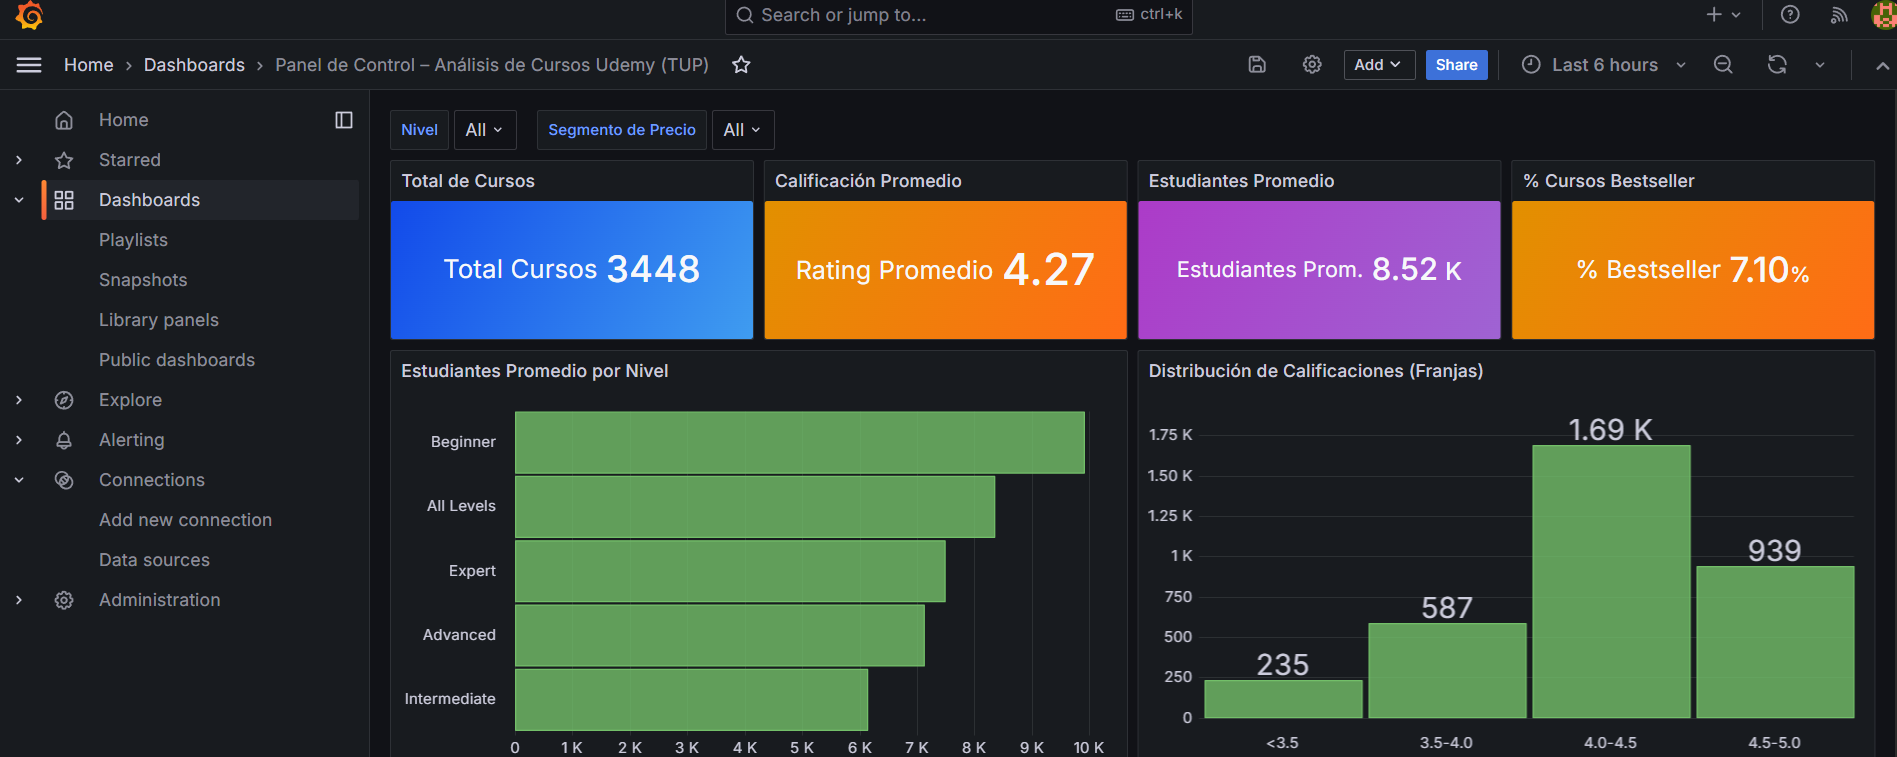

In [ ]:
# Vista previa del tablero de Grafana 
from IPython.display import Image
Image("grafana_preview.png")

---
## Hito 5: Informe de Gestión y Propuesta de Mejora 🚀

### 1. Diagnóstico Académico
A partir de la evidencia del análisis y del tablero, los hallazgos principales son:

- **La calificación no diferencia:** el 40 % de los cursos supera 4.5 y casi ninguno baja de 3.5. Un buen rating es la norma, por lo que **no sirve como única señal de calidad** para priorizar o auditar cursos.
- **El precio es irrelevante para la calidad:** la correlación precio–rating es ≈0.07. Cobrar más no implica mejores resultados.
- **El alcance lo define el nivel, no el "tamaño" del curso:** los cursos **Beginner/All Levels** concentran el mayor número de estudiantes, mientras que duración y cantidad de clases no inciden.
- **Punto ciego de feedback:** los cursos más masivos tienen un **ratio reseñas/estudiante hasta 6 veces menor** (≈0.02 vs ≈0.12). Reciben proporcionalmente muy poco feedback, lo que retrasa la detección de problemas de calidad justo donde hay más alumnos en juego.

### 2. Propuestas de Mejora (justificadas en datos)

* **Propuesta A — Política de "feedback proporcional" en cursos masivos.**
    * **Justificación:** la Visualización 6 muestra que los cursos del top 10% por estudiantes tienen un ratio reseñas/estudiante ≈0.02. Implementar recordatorios de reseña y encuestas intermedias en esos cursos aumentaría la muestra de feedback y permitiría detectar caídas de calidad de forma temprana, usando el KPI/% y los filtros del dashboard para monitorearlo por nivel.

* **Propuesta B — Reasignar la inversión de contenido hacia niveles introductorios y desacoplarla del precio.**
    * **Justificación:** las Visualizaciones 2, 4 y 5 muestran que el alcance se concentra en Beginner/All Levels y que duración, cantidad de clases y precio no se asocian con más estudiantes ni mejor rating. Conviene priorizar la producción de contenido introductorio de calidad (mayor demanda potencial) en lugar de cursos más largos o más caros, que no mejoran los resultados.

### 3. Conclusión Final
La implementación de estas propuestas desplazaría las decisiones desde supuestos ("más caro/más largo es mejor") hacia **evidencia**. Cerrar el punto ciego de feedback en los cursos masivos protegería a la mayor parte del alumnado, y reorientar la inversión hacia los niveles de mayor demanda mejoraría el retorno del esfuerzo de producción. El tablero de Grafana queda como herramienta de monitoreo continuo para que la coordinación valide el impacto de cada acción en tiempo real.